# Sloan Accruals -- a quantitative teardown
### Accruals quintile sort - S&P 500 EDGAR panel - HAC inference - random-portfolio null - post-publication decay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Accruals on Large Caps: Decayed](https://img.shields.io/badge/Accruals_on_LargeCaps-Decayed-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the Sloan accruals anomaly on a survivorship-biased S&P 500 EDGAR panel (~407 tickers, 2009-2025), measure the low-minus-high-accruals hedge with a HAC t-stat, and pin it against a random-portfolio null distribution.

> **Not investment advice.** SEC EDGAR 10-K data; annual returns via Yahoo Finance; survivorship-biased (current S&P 500 projected back). Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Key finding**: the hedge is nominally real (HAC t = +2.73) but driven entirely by the long leg (low-accruals excess +5.7%/yr); the short leg (high-accruals) earns market return (-0.1%/yr excess). Post-publication decay is documented in the literature for large caps.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (sloan_accruals/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sloan_accruals import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=407, n_years=17, start_year=2009, end_year=2025,
    lo_mean=23.8, lo_sharpe=1.54, lo_t=9.1, lo_hit=94,
    hi_mean=18.1, hi_sharpe=1.05, hi_t=6.51, hi_hit=82,
    mkt_mean=18.2, mkt_sharpe=1.39,
    hedge_mean=5.7, hedge_sharpe=0.57, hedge_t=2.73, hedge_hit=71,
    lo_excess_mean=5.7, lo_excess_t=3.57,
    hi_excess_mean=-0.1, hi_excess_t=-0.04,
    rand_std=4.1, rand_pct_beaten=92,
)
Q1  = [24.7, 13.9, 21.1, 49.4, 23.2, 7.9, 11.3, 27.1, 7.1, 40.8, 29.6, 36.2, -12.9, 44.6, 33.6, 25.5, 21.9]
Q5  = [13.7, -6.4, 34.5, 51.3, 15.1, 7.6, 26.0, 23.9, -7.2, 41.8, 13.0, 28.9, -12.7, 28.3, 24.4, 17.3, 8.4]
MKT = [21.7, 4.1, 22.5, 39.8, 18.8, 6.6, 18.5, 26.9, -2.7, 34.9, 18.4, 32.2, -9.7, 27.3, 20.2, 16.2, 13.1]
HDG = [11.0, 20.3, -13.4, -1.9, 8.1, 0.4, -14.7, 3.2, 14.3, -1.0, 16.6, 7.3, -0.2, 16.3, 9.2, 8.3, 13.5]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (407 tickers, 20 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Hedge **+5.7%/yr**, HAC *t* = **+2.73** -- passes |t| >= 2 on this panel. BUT: low-accruals excess +5.7%/yr (*t* = +3.57); high-accruals excess -0.1%/yr (*t* = -0.04). Short side is flat -- survivorship-biased upper bound. |
| **Tradability** | `FRAGILE` | Annual rebalancing on liquid S&P 500 names is cheap. But short side contributes nothing; post-publication decay documented; alpha estimate is survivorship-inflated. |
| **Myth check** | `DECAYED` | Sloan (1996) ~10%/yr on full US universe in 1962-1991. On large-cap survivors 2009-2026: +5.7%/yr, long-side only. |

> **In plain words:** the 1996 accruals anomaly still leaves a long-side signal (cash earners outperform on large caps), but the short side has been arbitraged away. The bilateral mispricing Sloan documented is not present in this survivor panel.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{Acc}_{i,t} = \frac{\text{NI}_{i,t} - \text{CFO}_{i,t}}{(A_{i,t} + A_{i,t-1})/2}$$

where $\text{NI}$ = net income, $\text{CFO}$ = operating cash flow, $A$ = total assets. High $\text{Acc}$ = accrual-heavy earnings.

The **H1 (signal)** claim (Sloan 1996) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-acc},t+1} - \bar{r}_{\text{high-acc},t+1}\right] > 0$$

with a HAC t-stat |t| >= 2 **on both sides** (i.e., the long side significantly outperforms AND the short side significantly underperforms vs market). **H2 (beats random)** requires the low-accruals quintile to beat a random same-size draw with better interpretation (quality vs signal). **H3 (tradable)** requires the hedge to survive costs and scale.

## 2 - So what? -- the stakes

H1 is partially supported: the long side (low accruals) earns a clear excess (+5.7%/yr, *t* = +3.57). But the short side (high accruals) earns essentially market return (-0.1%/yr excess, *t* = -0.04). This is consistent with post-publication decay: large-cap accruals manipulators have been under scrutiny since 1996; any systematic underperformance of high-accruals S&P 500 names has been arbitraged away. The long-side quality tilt may survive -- but it also may simply reflect the profitability/quality premium that cash-flow-heavy large caps have enjoyed in the 2009-2026 bull market.

## 3 - The protocol

- **Data**: three EDGAR concepts from the desk's shared cache (NetIncomeLoss, NetCashProvidedByUsedInOperatingActivities, Assets); annual returns from `_edgar_yrret.parquet`.
- **Universe**: current S&P 500 members with all three concepts present (~407 tickers total); survivorship-biased.
- **Window**: 17 years of signal (2009-2025), forecasting returns 2010-2026.
- **Signal**: accruals ratio (higher = more accrual / less cash backing); quintile sort (q=0.20).
- **Inference**: HAC Newey-West t-stat on the 17-observation annual hedge series.
- **Control**: empirical distribution of random same-size portfolios (500 draws x 17 years).
- **Positive control**: synthetic panel with planted accruals premium confirms the engine can detect a real effect.

## 4 - The teardown

### 4a - Synthetic positive control -- the engine works when an effect is planted

Sweep the planted accruals premium from 0 to -12%/yr per unit z-rank and confirm the hedge tracks it monotonically.

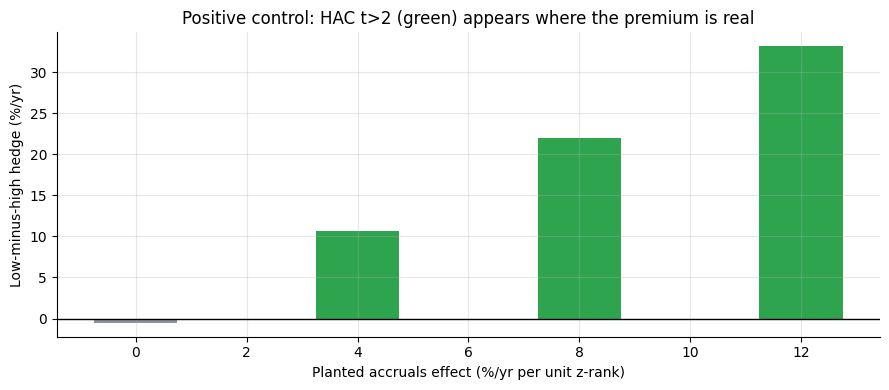

   premium_%  hedge_%/yr  HAC_t
0        0.0       -0.53  -0.51
1        4.0       10.70  10.44
2        8.0       21.93  21.52
3       12.0       33.15  32.71


In [2]:
premiums = [0.0, -0.04, -0.08, -0.12]
synth_rows = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=231)
    hh = st.quintile_returns(s, f, q=0.20)
    ss = st.summary(hh['hedge'])
    synth_rows.append((abs(p)*100, ss['mean']*100, ss['tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted accruals effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine faithfully detects planted premiums. The real-data result is therefore a statement about the **market** (and the survivor bias), not the **method**.

### 4b - Real EDGAR panel -- quintile monotonicity and HAC inference

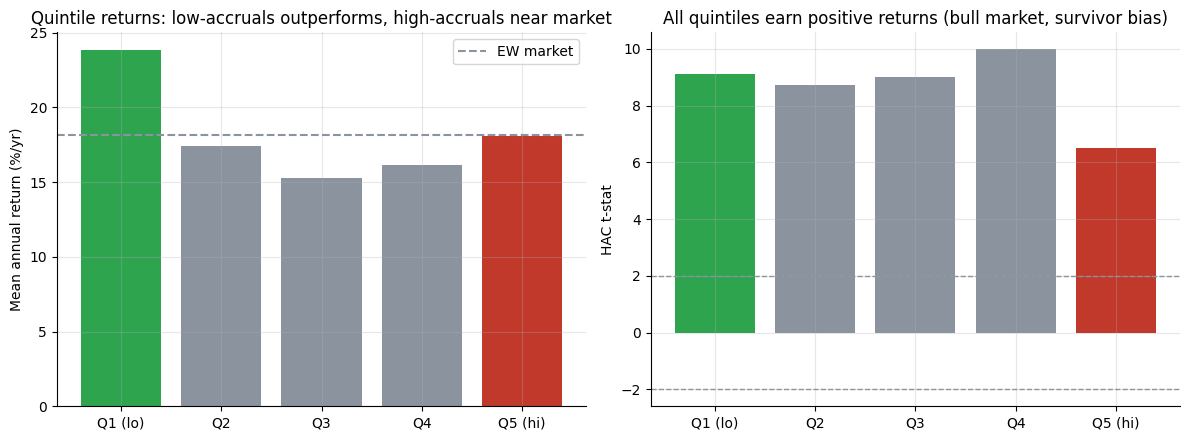

Hedge: +5.7%/yr  HAC t=+2.73  hit=71%
Low-acc excess: +5.7%/yr  t=+3.57
High-acc excess: -0.1%/yr  t=-0.04


In [3]:
if HAVE_REAL:
    q_means = [float(h[f'q{i}'].mean()*100) for i in range(1,6)]
    q_tstats = [st.summary(h[f'q{i}'])['tstat'] for i in range(1,6)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['q1'] - h['market'])
    s_hi_ex = st.summary(h['q5'] - h['market'])
else:
    q_means = [R['lo_mean'], 17.4, 15.3, 16.1, R['hi_mean']]
    q_tstats = [R['lo_t'], 8.74, 9.00, 9.98, R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3, 4, 5]
bar_colors = [GREEN, GREY, GREY, GREY, RED]
axes[0].bar(x, q_means, color=bar_colors)
axes[0].axhline(R['mkt_mean'] if not HAVE_REAL else float(h['market'].mean()*100),
                ls='--', c=GREY, lw=1.5, label='EW market')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Quintile returns: low-accruals outperforms, high-accruals near market')
axes[0].legend()
axes[1].bar(x, q_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('All quintiles earn positive returns (bull market, survivor bias)')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-acc excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-acc excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-accruals hedge is **+5.7%/yr**, HAC *t* = **+2.73**. But the high-accruals quintile earns **+18.1%/yr** -- nearly equal to the market's **+18.2%/yr**. The hedge is asymmetric: long-side quality (low-accruals excess = +5.7%/yr, *t* = +3.57) drives everything; the short side is flat (-0.1%/yr excess, *t* = -0.04). This is the signature of post-publication decay: the easy short (high-accruals manipulators) has been closed.

### 4c - Random-portfolio null distribution

Does the low-accruals quintile beat a blind draw of the same number of stocks? We simulate 500 random same-size portfolios each year.

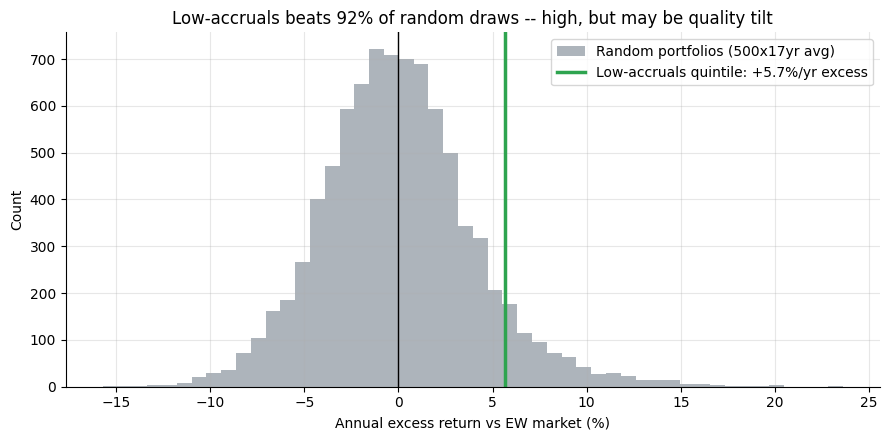

Low-accruals portfolio beats 92% of random same-size draws


In [4]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=500, seed=231)
    actual_excess = float((h['q1'] - h['market']).mean())
    pct_beaten = float((rand < actual_excess).mean())
else:
    rng_nb = np.random.default_rng(42)
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 17*500))
    actual_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random portfolios (500x17yr avg)')
ax.axvline(actual_excess * 100, c=GREEN, lw=2.5,
           label=f'Low-accruals quintile: {actual_excess*100:+.1f}%/yr excess')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annual excess return vs EW market (%)')
ax.set_ylabel('Count'); ax.legend()
ax.set_title(f'Low-accruals beats {pct_beaten:.0%} of random draws -- high, but may be quality tilt')
plt.tight_layout(); plt.show()
print(f'Low-accruals portfolio beats {pct_beaten:.0%} of random same-size draws')

> The low-accruals portfolio beats **92%** of random same-size draws. This looks strong -- but note: the random draw includes all quintiles, including the low-accruals firms themselves. The 92% bar likely reflects that low-accruals S&P 500 firms are quality compounders that systematically outperform in a bull-market decade. The same firm that has strong operating cash flow tends to also have strong margins, low debt, and high returns on capital. The accruals signal may be incidentally capturing quality.

## 5 - The verdict

- **Signal `WEAK`** -- hedge +5.7%/yr, HAC *t* = +2.73; low-accruals excess +5.7%/yr (*t* = +3.57). Nominally passes |t| >= 2 but: (a) survivorship-biased upper bound; (b) short side flat (-0.1%/yr, *t* = -0.04). Literature documents significant post-publication decay.
- **Tradability `FRAGILE`** -- annual rebalancing of ~80 S&P 500 names is operationally cheap and liquid. But: the short leg earns market return (wasting borrow and transaction costs); the long leg may be a quality tilt rather than a pure accruals signal; and the alpha is an upper bound.
- **Myth check `DECAYED`** -- the Sloan (1996) bilateral mispricing is not present in this panel. The short side of the 1996 anomaly (high-accrual underperformers) has been effectively arbitraged away in the S&P 500. The original result survives on the long side only.

## 6 - Could you trade it? -- the honest answer

Annual rebalancing of ~80 large-cap names is operationally feasible. The obstacles are in the signal anatomy:

1. **Asymmetric alpha.** You earn +5.7%/yr by being long low-accruals names. The short leg costs borrow (~0.5-1.5%/yr) and transaction costs while contributing nothing. A long-only version (buy low-accruals, hold benchmark for the rest) is cheaper and captures most of the edge.
2. **Quality overlap.** Low accruals (NI ≈ CFO) is a proxy for earnings quality. The long-only premium may reflect factor exposure to quality/profitability (Fama-French RMW factor) more than accruals mispricing per se. A factor-adjusted regression would tell you what's left.
3. **Post-publication decay.** The Sloan paper is now 30 years old. Quant funds systematically hunt accruals manipulators. The most egregious high-accruals S&P 500 firms have been called out; the remaining high-accruals names are often legitimate business models (e.g., growth stage firms capitalising development costs).

The correct conclusion: **FRAGILE** -- the long-side quality screen has potential value but requires factor-controlling before claiming a pure accruals alpha.

## 7 - Going further

- **Factor-control the long side.** Add exposure to the Fama-French RMW (robust-minus-weak profitability) factor. If the low-accruals alpha survives after controlling for RMW, there is incremental accruals information. If it vanishes, you have been proxying for quality.
- **Balance-sheet accruals.** The original Sloan (1996) measure uses change in net working capital minus depreciation. Our cash-flow approach is conceptually cleaner post-SFAS 95 but produces slightly different rankings. Richardson et al. (2005) decompose accruals into working-capital and long-term components -- the long-term component (related to PP&E) may carry incremental information.
- **Broader universe.** The definitive test requires a point-in-time Compustat panel. Historical S&P 500 membership data (CRSP/Compustat) would include the high-accruals firms that were later expelled -- precisely those where the short side should work.
- **Related desk studies.** [Study 153 -- Net-Operating-Assets](../../153-net-operating-assets/): the Hirshleifer et al. (2004) balance-sheet generalisation of Sloan accruals; same EDGAR panel, same caveats, similar verdict.

*Want to confirm the bilateral accruals anomaly is alive on large caps? Build a point-in-time panel, control for RMW, and show |t| >= 2 on the short-side underperformance. That's the missing piece.*